1) When Decision Tree Regression is used

Use when target is a number.

Example:

salary prediction
price prediction
sales prediction

In [1]:
import pandas as pd

data = {
    'Experience': [1,2,3,4,5,6],
    'Salary': [25,30,35,50,65,80]
}

df = pd.DataFrame(data)

print(df)

   Experience  Salary
0           1      25
1           2      30
2           3      35
3           4      50
4           5      65
5           6      80


In [2]:
X = df[['Experience']]
y = df['Salary']

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
X_train

,Experience
5,6
2,3
4,5
3,4


In [5]:
X_test

,Experience
0,1
1,2


In [6]:
y_train

5    80
2    35
4    65
3    50
Name: Salary, dtype: int64

In [7]:
y_test 

0    25
1    30
Name: Salary, dtype: int64

In [8]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()

In [9]:
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [10]:
#Predit new value
prediction1 = model.predict([[7]])    

prediction = model.predict([[3.5]])

print(prediction)

print(prediction1)

[35.]
[80.]


c:\DS2026\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
c:\DS2026\Python\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [11]:
y_pred = model.predict(X_test)

print(y_pred)

[35. 35.]


Compare Actual vs Predicted

In [12]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(result)

   Actual  Predicted
0      25       35.0
1      30       35.0


In [ ]:
#13) Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print(mae)

7.5


In [14]:
#14) Mean Squared Error (MSE)

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print(mse)

62.5


In [15]:
#RMSE

import numpy as np

rmse = np.sqrt(mse)

print(rmse)

7.905694150420948


In [16]:
#16) R² Score

from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print(r2)

-9.0


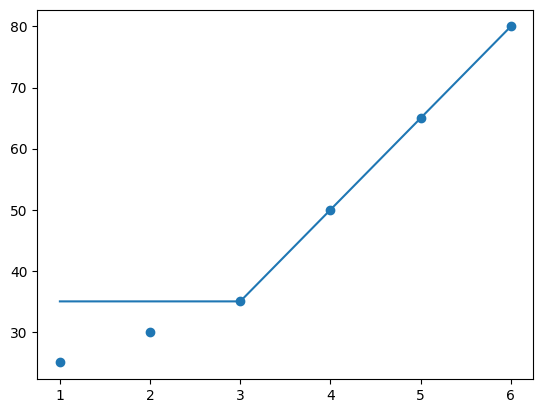

In [17]:
# Visualize Prediction
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.show()